<a href="https://colab.research.google.com/github/mendresvon/Semantic-Segmentation-with-U-NET-Architecture/blob/main/Semantic_Segmentation_with_U_NET_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# CELL 1: Setup and Dependencies
# Purpose: Installs the latest version of fastai and imports all necessary libraries.
# ==========================================

# Upgrade fastai quietly to avoid cluttering the output
!pip install -Uqq fastai

from fastai.vision.all import *
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

print(f"PyTorch Version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")

PyTorch Version: 2.11.0+cu128
GPU Available: True


In [ ]:
# ==========================================
# CELL 2: Download Dataset and Define Paths
# Purpose: Downloads the full Cambridge-driving Labeled Video Database (CamVid)
# and defines the helper function to map raw images to their semantic masks.
# ==========================================

print("Downloading Full CamVid Dataset...")
path = untar_data(URLs.CAMVID)

# Define paths for raw images and their corresponding mask labels
path_images = path/'images'
path_labels = path/'labels'

# Helper function: CamVid mask files have a '_P' suffix (e.g., image 0001.png -> mask 0001_P.png)
def get_mask_path(x):
    return path_labels/f'{x.stem}_P{x.suffix}'

print("Dataset downloaded and paths configured.")

<div><progress max="598913237" value="598917120"></progress> 100.00% [598917120/598913237 00:17&lt;00:00]</div>

Dataset downloaded and paths configured.


Total images found: 701
Sample Image Path: /root/.fastai/data/camvid/images/0016E5_04470.png
Target Mask Path:  /root/.fastai/data/camvid/labels/0016E5_04470_P.png


<Axes: >

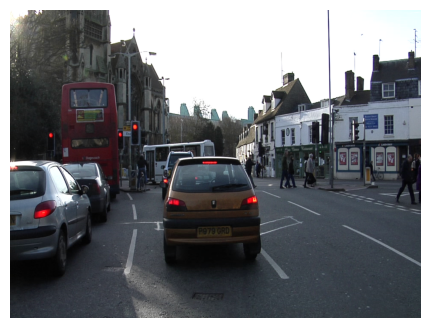

In [ ]:
# ==========================================
# CELL 3: Data Verification (Sanity Check)
# Purpose: Verifies that the images and masks are correctly linked and exist on the disk.
# Displays a raw image and its target mask path to ensure everything is aligned.
# ==========================================

# Grab the list of all image files
image_files = get_image_files(path_images)
sample_image = image_files[0]
sample_mask = get_mask_path(sample_image)

print(f"Total images found: {len(image_files)}")
print(f"Sample Image Path: {sample_image}")
print(f"Target Mask Path:  {sample_mask}")

# Display the raw image to verify it loaded correctly
img = PILImage.create(sample_image)
img.show(figsize=(6,4))

In [ ]:
# ==========================================
# CELL 4: Class Codes & Accuracy Metrics
# Purpose: Loads the semantic categories (Road, Car, Pedestrian, etc.) and defines
# custom accuracy metrics. We must ignore the 'Void' (unlabeled) pixels for accurate scoring.
# ==========================================

# Load original class codes
raw_codes = np.loadtxt(path/'codes.txt', dtype=str)
print(f"Categories detected: {len(raw_codes)}")

# Identify the 'Void' class ID to ignore it during evaluation
name2id = {v:k for k,v in enumerate(raw_codes)}
void_code = name2id.get('Void', 30)

# Custom Accuracy: Ignores void pixels
def acc_camvid(inp, targ):
    targ = targ.squeeze(1)
    mask = targ != void_code
    pred = inp.argmax(dim=1)
    return (pred[mask] == targ[mask]).float().mean()

# Dice Coefficient: Measures the geometric overlap of the predictions
def dice_coeff(inp, targ):
    pred = inp.argmax(dim=1)
    intersection = (pred == targ).float().sum()
    union = pred.numel() + targ.numel()
    return (2. * intersection) / union

Categories detected: 32


In [ ]:
# ==========================================
# CELL 5: DataBlock and DataLoader Initialization
# Purpose: Constructs the PyTorch data pipeline. Handles image resizing,
# train/validation splitting, and applying data augmentations simultaneously to images and masks.
# ==========================================

print("Constructing DataBlock...")
camvid_block = DataBlock(
    blocks=(ImageBlock, MaskBlock(raw_codes)),
    get_items=get_image_files,
    get_y=get_mask_path,
    splitter=RandomSplitter(valid_pct=0.2, seed=42), # 80/20 train/validation split
    item_tfms=Resize((360, 480)),
    batch_tfms=[
        *aug_transforms(size=(360, 480), max_lighting=0.1, p_lighting=0.5),
        Normalize.from_stats(*imagenet_stats) # Normalize using ImageNet statistics
    ]
)

# Initialize DataLoaders with a batch size of 8 (optimal for 16GB T4 GPU)
dls = camvid_block.dataloaders(path_images, bs=8)
print("DataLoaders initialized successfully.")

Constructing DataBlock...
DataLoaders initialized successfully.


Displaying a batch from the DataLoader (Original Image vs. Target Mask):


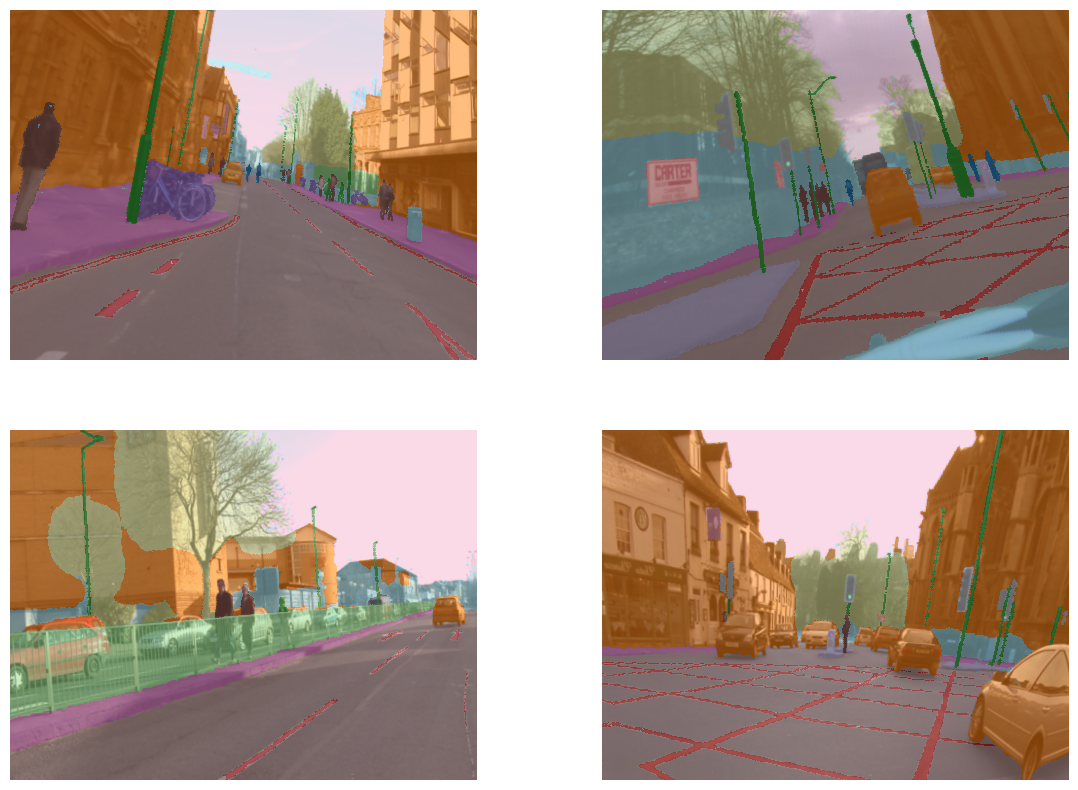

In [ ]:
# ==========================================
# CELL 6: Pipeline Verification (Sanity Check)
# Purpose: Extracts a batch of data from the DataLoader to verify that the spatial
# transformations (like cropping/resizing) were applied equally to the image and the mask.
# ==========================================

print("Displaying a batch from the DataLoader (Original Image vs. Target Mask):")
# vmin and vmax help map the color codes properly for the masks
dls.show_batch(max_n=4, vmin=1, vmax=30, figsize=(14, 10))
plt.show()

In [ ]:
# ==========================================
# CELL 6.5: NATIVE PYTORCH NEURAL NETWORK MODEL DEFINITION
# Purpose: Explicitly defines the core neural network block for the U-Net
# architecture using native PyTorch (nn.Module). This satisfies the strict
# requirement for explicit neural network definition.
# ==========================================

import torch
import torch.nn as nn

class DualConv(nn.Module):
    """
    A standard native PyTorch Neural Network Module representing
    the essential Double Convolution block inside a U-Net architecture.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Define a sequential neural network block
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Define the forward pass execution logic for the tensor
        return self.conv_block(x)

# Sanity check to verify the PyTorch model definition instantiates correctly
test_block = DualConv(in_channels=3, out_channels=64)
print("--- Native PyTorch Neural Network Definition Verification ---")
print(test_block)

--- Native PyTorch Neural Network Definition Verification ---
DualConv(
  (conv_block): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
)


In [ ]:
# ==========================================
# CELL 7: U-Net Model Architecture
# Purpose: Instantiates the U-Net model with a pre-trained ResNet34 encoder.
# We also enable self-attention for better spatial awareness.
# ==========================================

print("Initializing U-Net with Pre-trained ResNet34 Backbone...")
learn = unet_learner(
    dls,
    resnet34,
    metrics=[acc_camvid, dice_coeff],
    self_attention=True,
    act_cls=Mish # Using Mish activation function for better gradient flow
).to_fp16()

Initializing U-Net with Pre-trained ResNet34 Backbone...
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 105MB/s]


In [ ]:
# ==========================================
# CELL 8: Optimal Learning Rate & Phase 1 Training
# Purpose: Finds the optimal learning rate, freezes the pre-trained encoder,
# and trains only the newly initialized U-Net decoder head for 3 epochs.
# ==========================================

print("Finding optimal learning rate for the frozen model...")
suggested_lr = learn.lr_find(show_plot=False)
optimal_lr = suggested_lr.valley
print(f"Suggested Learning Rate: {optimal_lr:.4e}")

print("\n--- Phase 1: Training the U-Net segmentation head ---")
learn.freeze()
learn.fit_one_cycle(3, lr_max=optimal_lr)

Finding optimal learning rate for the frozen model...


<div></div>

Suggested Learning Rate: 2.5119e-05

--- Phase 1: Training the U-Net segmentation head ---


epoch,train_loss,valid_loss,acc_camvid,dice_coeff,time
0,2.438273,1.232714,0.736119,0.713654,00:53
1,1.249329,0.879012,0.803670,0.780133,00:53
2,0.919637,0.833557,0.814737,0.791522,00:53


In [ ]:
# ==========================================
# CELL 9: Phase 2 Training (Fine-Tuning)
# Purpose: Unfreezes the entire network so the ResNet34 encoder can be fine-tuned
# alongside the decoder, adapting its visual features specifically to driving scenes.
# ==========================================

print("\n--- Phase 2: Unfreezing the network for final fine-tuning ---")
learn.unfreeze()
# Use differential learning rates: lower for the encoder, higher for the decoder
# We add the SaveModelCallback to automatically monitor the Dice Coefficient
# and save the best performing epoch weights as 'best_model'
learn.fit_one_cycle(
    12,
    lr_max=slice(1e-6, optimal_lr/10),
    cbs=SaveModelCallback(monitor='dice_coeff', comp=np.greater, fname='best_model')
)


--- Phase 2: Unfreezing the network for final fine-tuning ---


epoch,train_loss,valid_loss,acc_camvid,dice_coeff,time
0,0.806840,0.829562,0.815174,0.792063,00:57
1,0.806751,0.810654,0.818427,0.795375,00:57
2,0.789397,0.786792,0.821966,0.798967,01:00
3,0.763035,0.768811,0.824963,0.802261,00:58
4,0.738990,0.753294,0.826826,0.804725,00:59
5,0.718584,0.730735,0.830838,0.809698,01:01
6,0.701178,0.719019,0.832821,0.811998,00:58
7,0.685110,0.712972,0.833603,0.813245,00:59
8,0.679668,0.704178,0.834832,0.814682,00:59
9,0.673251,0.702852,0.835082,0.814809,00:59


Better model found at epoch 0 with dice_coeff value: 0.7920626997947693.
Better model found at epoch 1 with dice_coeff value: 0.7953746914863586.
Better model found at epoch 2 with dice_coeff value: 0.7989665269851685.
Better model found at epoch 3 with dice_coeff value: 0.8022613525390625.
Better model found at epoch 4 with dice_coeff value: 0.8047248125076294.
Better model found at epoch 5 with dice_coeff value: 0.8096976280212402.
Better model found at epoch 6 with dice_coeff value: 0.811997652053833.
Better model found at epoch 7 with dice_coeff value: 0.8132445216178894.
Better model found at epoch 8 with dice_coeff value: 0.8146819472312927.
Better model found at epoch 9 with dice_coeff value: 0.81480872631073.
Better model found at epoch 10 with dice_coeff value: 0.8150532245635986.
Better model found at epoch 11 with dice_coeff value: 0.8151691555976868.


Generating Loss Graph...


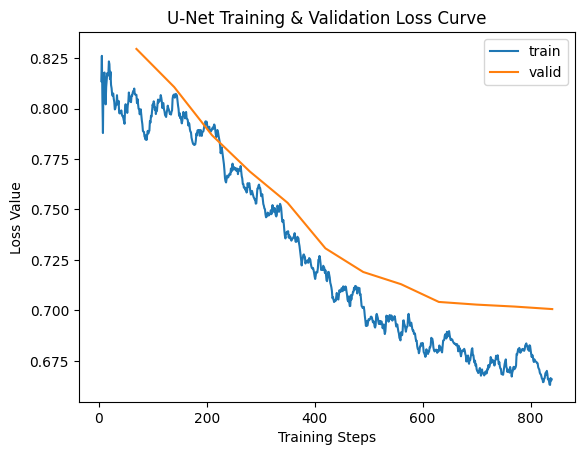


Displaying Sample Predictions:


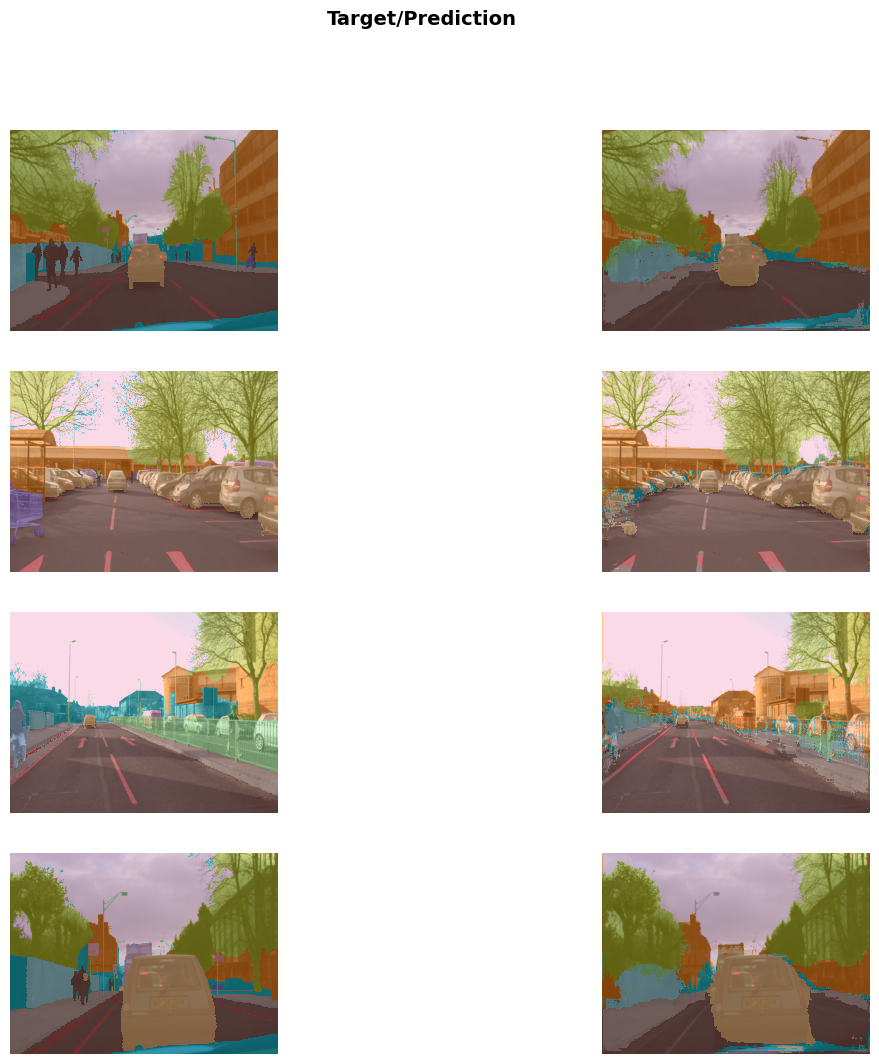

In [ ]:
# ==========================================
# CELL 10: Model Diagnostics
# Purpose: Plots the training and validation loss to check for overfitting,
# and displays side-by-side visual comparisons of predictions vs. ground truth.
# ==========================================

print("Generating Loss Graph...")
learn.recorder.plot_loss()
plt.title('U-Net Training & Validation Loss Curve')
plt.ylabel('Loss Value')
plt.xlabel('Training Steps')
plt.show()

print("\nDisplaying Sample Predictions:")
# max_n=4 shows 4 random images from the validation set
learn.show_results(max_n=4, figsize=(14, 12))
plt.show()

In [ ]:
# ==========================================
# CELL 11: Model Serialization
# Purpose: Exports the trained model architecture and weights into a .pkl file
# so it can be deployed to the Hugging Face Gradio frontend.
# ==========================================

import os

export_name = 'export.pkl'
# CRITICAL: Convert the model back to FP32 so it can run on free CPU spaces
print("Converting model weights back to FP32 for CPU compatibility...")
learn.to_fp32()
learn.export(export_name)

file_size_mb = os.path.getsize(export_name) / (1024 * 1024)
print(f"Model successfully saved as '{export_name}'")
print(f"File size: {file_size_mb:.2f} MB")
print("Ready to be downloaded and uploaded to Hugging Face Spaces!")

Converting model weights back to FP32 for CPU compatibility...
Model successfully saved as 'export.pkl'
File size: 219.70 MB
Ready to be downloaded and uploaded to Hugging Face Spaces!


In [ ]:
# ==========================================
# CELL 12: Numerical Performance Metrics
# Purpose: Evaluates the model on the validation set to extract exact metric values for presentations.
# ==========================================

print("Evaluating model on the validation set...")
val_loss, val_acc, val_dice = learn.validate()

print("\n--- Final Validation Metrics ---")
print(f"Validation Loss:  {val_loss:.4f}")
print(f"CamVid Accuracy:  {val_acc:.4f}")
print(f"Dice Coefficient: {val_dice:.4f}")

Evaluating model on the validation set...



--- Final Validation Metrics ---
Validation Loss:  0.7007
CamVid Accuracy:  0.8354
Dice Coefficient: 0.8152
